# Notebook 21: EMC-GCN Remake

Reimplementasi model **EMC-GCN** (Enhanced Multi-Channel Graph Convolutional Network) menggunakan **PyABSA** pada dataset yang sama dengan STL dan MTL, dengan split 85/15 (seed=42) untuk perbandingan yang konsisten.

**Tujuan**: Menghasilkan prediksi BIEOS dari EMC-GCN yang bisa dibandingkan langsung dengan STL (F1=0.7600) dan MTL (F1=0.7578) di notebook 14–20.

**Referensi**: Istadewanti (2025) — EMC-GCN pada dataset ini mencapai F1≈0.6761.

## 0. Setup

In [1]:
import os
import ast
import json
import string
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
from seqeval.metrics import classification_report, f1_score as seq_f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

BASE_DIR        = os.path.dirname(os.getcwd())
DATA_RAW_DIR    = os.path.join(BASE_DIR, 'data', 'raw')
DATA_PROC_DIR   = os.path.join(BASE_DIR, 'data', 'processed')
MODELS_DIR      = os.path.join(BASE_DIR, 'models')

os.makedirs(MODELS_DIR, exist_ok=True)

RAW_FILE  = os.path.join(DATA_RAW_DIR, 'ABSA_all_2500data_train.txt')
VAL_FILE  = os.path.join(DATA_PROC_DIR, 'train_data_bieos_val.json')

# PyABSA dataset: nama pendek + direktori di dalam notebooks/integrated_datasets/aste_datasets/
# PyABSA mencari dari CWD (notebooks/) dengan findfile.find_dir(cwd, [name, 'ASTE', 'dataset'])
PYABSA_DATASET_NAME = 'my_aste_data'
PYABSA_DATASET_DIR  = os.path.join('integrated_datasets', 'aste_datasets', PYABSA_DATASET_NAME)
os.makedirs(PYABSA_DATASET_DIR, exist_ok=True)

print(f'BASE_DIR          : {BASE_DIR}')
print(f'PYABSA_DATASET_DIR: {PYABSA_DATASET_DIR}')

BASE_DIR          : d:\Kuliah\TA\TA_Notebook
PYABSA_DATASET_DIR: integrated_datasets\aste_datasets\my_aste_data


## 1. Data Preparation

### 1.1 Parse Raw Data

Format raw: `sentence####[([asp_idx], [op_idx], 'POLARITY'), ...]`

Kita perlu **aspect + opinion indices** untuk training EMC-GCN (ASTE task).

In [2]:
raw_data = []

with open(RAW_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line or '####' not in line:
            continue
        text_part, label_part = line.split('####', 1)
        text_part = text_part.strip()
        tokens = text_part.split()
        if not tokens:
            continue
        try:
            triplets = ast.literal_eval(label_part.strip())
        except (ValueError, SyntaxError):
            continue
        raw_data.append({
            'text': text_part,
            'tokens': tokens,
            'triplets': triplets,  # [(asp_indices, op_indices, polarity), ...]
        })

print(f'Total raw samples: {len(raw_data)}')

Total raw samples: 2511


### 1.2 Filter (sama dengan NB01)

Hapus sampel dengan < 3 token atau tidak ada aspek valid.

In [3]:
MIN_TOKENS = 3

filtered = []
for d in raw_data:
    tokens = d['tokens']
    triplets = d['triplets']
    # Cek ada aspek valid
    has_valid_aspect = any(
        len(asp) > 0 and any(i < len(tokens) for i in asp)
        for asp, op, sent in triplets
    )
    if len(tokens) >= MIN_TOKENS and has_valid_aspect:
        filtered.append(d)

print(f'Sebelum filter: {len(raw_data)}')
print(f'Sesudah filter: {len(filtered)}')
print(f'Dibuang       : {len(raw_data) - len(filtered)}')

Sebelum filter: 2511
Sesudah filter: 2451
Dibuang       : 60


### 1.3 Split 85/15 (seed=42)

Split yang sama dengan NB03 (STL/MTL) untuk konsistensi.

In [4]:
train_data, val_data = train_test_split(filtered, test_size=0.15, random_state=SEED)

print(f'Train: {len(train_data)}')
print(f'Val  : {len(val_data)}')
print(f'Total: {len(train_data) + len(val_data)}')

Train: 2083
Val  : 368
Total: 2451


### 1.4 Verifikasi Alignment dengan train_data_bieos_val.json

Cek apakah kalimat di val_data kita match dengan yang ada di `train_data_bieos_val.json`  
(yang dipakai STL/MTL). Alignment tidak harus 100% persis karena NB01 memakai slang normalization.

In [5]:
# Load val dari STL/MTL
with open(VAL_FILE, 'r', encoding='utf-8') as f:
    stl_val = json.load(f)

stl_val_sentences = set(' '.join(d['tokens']) for d in stl_val)
our_val_sentences  = set(' '.join(d['tokens']) for d in val_data)

overlap = stl_val_sentences & our_val_sentences
print(f'STL/MTL val set : {len(stl_val_sentences)} kalimat')
print(f'EMC-GCN val set : {len(our_val_sentences)} kalimat')
print(f'Overlap (exact) : {len(overlap)} kalimat ({len(overlap)/max(len(stl_val_sentences),1)*100:.1f}%)')
print()
print('Catatan: Overlap tidak 100% karena NB01 mengaplikasikan slang normalization.')
print('Untuk evaluasi EMC-GCN, kita pakai gold labels dari raw data (sebelum normalisasi).')

STL/MTL val set : 368 kalimat
EMC-GCN val set : 368 kalimat
Overlap (exact) : 55 kalimat (14.9%)

Catatan: Overlap tidak 100% karena NB01 mengaplikasikan slang normalization.
Untuk evaluasi EMC-GCN, kita pakai gold labels dari raw data (sebelum normalisasi).


### 1.5 Buat Gold BIEOS Labels untuk Validasi

Karena EMC-GCN beroperasi di level raw token (tanpa slang normalization), kita buat gold BIEOS dari indeks aspek di raw data.

In [6]:
def build_gold_bieos(tokens, triplets):
    """Buat gold BIEOS labels dari aspect indices dan polarity."""
    labels = ['O'] * len(tokens)
    for asp_indices, op_indices, sentiment in triplets:
        valid_asp = sorted([i for i in asp_indices if 0 <= i < len(tokens)])
        if not valid_asp:
            continue
        sent = sentiment.upper()  # POS / NEG / NEU
        if len(valid_asp) == 1:
            labels[valid_asp[0]] = f'S-{sent}'
        else:
            labels[valid_asp[0]] = f'B-{sent}'
            for idx in valid_asp[1:-1]:
                labels[idx] = f'I-{sent}'
            labels[valid_asp[-1]] = f'E-{sent}'
    return labels

# Tambahkan gold BIEOS ke setiap sampel
for d in filtered:
    d['gold_labels'] = build_gold_bieos(d['tokens'], d['triplets'])

# Verifikasi
sample = val_data[0]
print('Contoh validasi gold:')
for tok, lbl in zip(sample['tokens'][:10], sample['gold_labels'][:10]):
    print(f'  {tok:20s}  {lbl}')

Contoh validasi gold:
  desa                  S-POS
  paling                O
  bersih                O
  dan                   O
  baik                  O


### 1.6 Konversi ke Format PyABSA ASTE

Format: `sentence####[(asp_indices, op_indices, polarity), ...]`

In [7]:
def to_pyabsa_line(d):
    """Konversi satu sampel ke format baris PyABSA ASTE."""
    text = d['text']
    tokens = d['tokens']
    valid_triplets = []
    for asp_idx, op_idx, sent in d['triplets']:
        asp_v = [i for i in asp_idx if 0 <= i < len(tokens)]
        op_v  = [i for i in op_idx  if 0 <= i < len(tokens)]
        if asp_v and op_v:
            valid_triplets.append((asp_v, op_v, sent))
    if not valid_triplets:
        return None
    return f"{text}####{valid_triplets}"

def write_pyabsa_file(data, path):
    lines = []
    skipped = 0
    for d in data:
        line = to_pyabsa_line(d)
        if line:
            lines.append(line)
        else:
            skipped += 1
    with open(path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))
    print(f'Saved {len(lines)} lines (skipped {skipped}) -> {path}')

# Simpan ke direktori yang dikenali PyABSA (relative dari CWD = notebooks/)
train_path = os.path.join(PYABSA_DATASET_DIR, 'train.txt')
valid_path = os.path.join(PYABSA_DATASET_DIR, 'valid.txt')
test_path  = os.path.join(PYABSA_DATASET_DIR, 'test.txt')

write_pyabsa_file(train_data, train_path)
write_pyabsa_file(val_data,   valid_path)
write_pyabsa_file(val_data,   test_path)   # test.txt diperlukan PyABSA

# Preview
print('Contoh baris train:')
with open(train_path, 'r', encoding='utf-8') as f:
    print(f.readline()[:120], '...')

Saved 2083 lines (skipped 0) -> integrated_datasets\aste_datasets\my_aste_data\train.txt
Saved 368 lines (skipped 0) -> integrated_datasets\aste_datasets\my_aste_data\valid.txt
Saved 368 lines (skipped 0) -> integrated_datasets\aste_datasets\my_aste_data\test.txt
Contoh baris train:
tempat menghilangkan penat , refreshing , outbond ada . udara sejuk .####[([0], [1, 2, 3, 4], 'POS'), ([6], [7], 'POS'), ...


## 2. EMC-GCN Training via PyABSA

Konfigurasi sama dengan original (EMCGCN_Model_and_Evaluation.ipynb) tapi:
- Seed: **42** (konsisten dengan STL/MTL, original pakai 52)
- Split: **85/15** (konsisten dengan STL/MTL, original pakai 70/15/15)
- Batch: **8** (VRAM safety, original pakai 16 di server)
- Patience: **5** (early stopping)
- Encoder: **indobert-large-p2** (sama dengan STL/MTL)

In [8]:
try:
    from pyabsa import AspectSentimentTripletExtraction as ASTE, ModelSaveOption
    print('PyABSA loaded successfully')
except ImportError:
    print('PyABSA tidak ditemukan. Install: pip install pyabsa')
    raise

<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


PyABSA loaded successfully


In [9]:
config = ASTE.ASTEConfigManager.get_aste_config_multilingual()

config.model           = ASTE.ASTEModelList.EMCGCN
config.pretrained_bert = 'indobenchmark/indobert-large-p2'
config.max_seq_len     = 100
config.batch_size      = 8           # reduce to 4 jika OOM
config.learning_rate   = 2e-5
config.num_epoch       = 50
config.patience        = 5           # early stopping
config.evaluate_begin  = 0
config.emb_dropout     = 0.5
config.dropout         = 0.5
config.l2reg           = 1e-6
config.seed            = SEED        # 42
config.optimizer       = 'adamw'
config.cache_dataset   = False
config.use_fp16        = False
config.log_step        = 110

# Checkpoint dir
config.model_path_to_save = MODELS_DIR

print('Config set:')
print(f'  model          : {config.model}')
print(f'  pretrained_bert: {config.pretrained_bert}')
print(f'  batch_size     : {config.batch_size}')
print(f'  num_epoch      : {config.num_epoch}')
print(f'  seed           : {config.seed}')

Config set:
  model          : <class 'pyabsa.tasks.AspectSentimentTripletExtraction.models.model.EMCGCN'>
  pretrained_bert: indobenchmark/indobert-large-p2
  batch_size     : 8
  num_epoch      : 50
  seed           : 42


In [10]:
# Training
# PyABSA mencari dataset dari CWD (notebooks/) menggunakan nama pendek PYABSA_DATASET_NAME.
# File dataset ada di: notebooks/integrated_datasets/aste_datasets/my_aste_data/

trainer = ASTE.ASTETrainer(
    config=config,
    dataset=PYABSA_DATASET_NAME,
    checkpoint_save_mode=ModelSaveOption.SAVE_MODEL_STATE_DICT,
    auto_device=True,
)

print('Training selesai.')

[2026-03-30 13:01:24] (2.4.3) Set Model Device: cuda:0
[2026-03-30 13:01:24] (2.4.3) Device Name: NVIDIA GeForce RTX 4060 Laptop GPU


d:\miniconda3\envs\ta_nlp\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


2026-03-30 13:01:25,232 INFO: PyABSA version: 2.4.3
2026-03-30 13:01:25,234 INFO: Transformers version: 4.29.2
2026-03-30 13:01:25,236 INFO: Torch version: 2.5.1+cu121+cuda12.1
2026-03-30 13:01:25,237 INFO: Device: NVIDIA GeForce RTX 4060 Laptop GPU
2026-03-30 13:01:25,248 INFO: Searching dataset my_aste_data in local disk
2026-03-30 13:01:25,259 INFO: You can set load_aug=True in a trainer to augment your dataset (English only yet) and improve performance.
2026-03-30 13:01:25,261 INFO: Please use a new folder to perform new text augment if the former augment in integrated_datasets\aste_datasets\my_aste_data errored unexpectedly


d:\miniconda3\envs\ta_nlp\lib\multiprocessing\pool.py:268: ResourceWarning: unclosed running multiprocessing pool <multiprocessing.pool.Pool state=RUN pool_size=1>
  _warn(f"unclosed running multiprocessing pool {self!r}",
Using eos_token, but it is not set yet.


2026-03-30 13:01:26,139 INFO: Load dataset from integrated_datasets\aste_datasets\my_aste_data\train.txt


...

[2026-03-30 13:29:13] (2.4.3) Loading best model: checkpoints/emcgcn_custom_dataset_f1_55.24/ and evaluating on test set 


d:\miniconda3\envs\ta_nlp\lib\site-packages\pyabsa\framework\instructor_class\instructor_template.py:117: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(find_file(

2026-03-30 13:29:20,063 INFO: 
----------------------------------------------------------------- Raw Metric Records -----------------------------------------------------------------
╒═════════════╤═══════════════════════════════════════════════════════╤════════════════════╤═══════════╤══════════╤═══════╤═══════╤═════════╤═════════╕
│ Metric      │ Trial                                                 │ Values             │  Average  │  Median  │  Std  │  IQR  │   Min   │   Max   │
╞═════════════╪═══════════════════════════════════════════════════════╪════════════════════╪═══════════╪══════════╪═══════╪═══════╪═════════╪═════════╡
│ Max-Test-F1 │ emcgcn-custom_dataset-indobenchmark/indobert-large-p2 │ [55.2414605418139] │  55.2415  │ 55.2415  │   0   │   0   │ 55.2415 │ 55.2415 │
╘═════════════╧═══════════════════════════════════════════════════════╧════════════════════╧═══════════╧══════════╧═══════╧═══════╧═════════╧═════════╛
--------------------------------------------------- https:

d:\miniconda3\envs\ta_nlp\lib\site-packages\pyabsa\framework\trainer_class\trainer_template.py:250: ResourceWarning: unclosed file <_io.TextIOWrapper name='d:\\Kuliah\\TA\\TA_Notebook\\notebooks\\logs\\emcgcn_20260330 130117\\trainer.log' mode='a' encoding='utf8'>
  self.config.logger.removeHandler(self.config.logger.handlers[0])


Training selesai.


### 2.1 Temukan Checkpoint Terbaik

In [11]:
import glob

# PyABSA menyimpan checkpoint di subfolder yang dibuat otomatis
# Cari checkpoint dengan pola '*emcgcn*' atau '*EMCGCN*'
checkpoint_candidates = glob.glob(os.path.join(MODELS_DIR, '**', '*emcgcn*'), recursive=True)
checkpoint_candidates += glob.glob(os.path.join(MODELS_DIR, '**', '*EMCGCN*'), recursive=True)

# Juga cari di working directory (PyABSA kadang simpan di sana)
checkpoint_candidates += glob.glob('**/*emcgcn*', recursive=True)
checkpoint_candidates += glob.glob('**/*EMCGCN*', recursive=True)

print('Checkpoint candidates found:')
for p in sorted(set(checkpoint_candidates)):
    print(f'  {p}')

if not checkpoint_candidates:
    print('WARNING: Tidak ada checkpoint ditemukan. Cek folder models/ dan working directory.')

Checkpoint candidates found:
  21_EMCGCN_Remake.ipynb
  checkpoints\emcgcn_custom_dataset_f1_55.24
  checkpoints\emcgcn_custom_dataset_f1_55.24\emcgcn.args.txt
  checkpoints\emcgcn_custom_dataset_f1_55.24\emcgcn.config
  checkpoints\emcgcn_custom_dataset_f1_55.24\emcgcn.state_dict
  checkpoints\emcgcn_custom_dataset_f1_55.24\emcgcn.tokenizer
  logs\emcgcn_20260330 123900
  logs\emcgcn_20260330 130117


## 3. Evaluasi — Prediksi pada Validation Set

Load checkpoint terbaik dan prediksi seluruh validation set.

In [12]:
# Ganti path ini dengan checkpoint terbaik yang ditemukan di atas
# Contoh: CHECKPOINT_PATH = 'models/emcgcn_indobert-large-p2_...'
# Atau biarkan PyABSA mencari sendiri dengan string partial name

CHECKPOINT_PATH = None  # diisi otomatis di bawah

# Coba ambil checkpoint terbaik dari candidates
if checkpoint_candidates:
    # Ambil direktori (bukan file individual)
    ckpt_dirs = set()
    for p in checkpoint_candidates:
        parent = os.path.dirname(p)
        if os.path.isdir(p):
            ckpt_dirs.add(p)
        else:
            ckpt_dirs.add(parent)
    CHECKPOINT_PATH = sorted(ckpt_dirs)[0]
    print(f'Menggunakan checkpoint: {CHECKPOINT_PATH}')
else:
    print('ERROR: Tidak ada checkpoint. Ganti CHECKPOINT_PATH secara manual.')

Menggunakan checkpoint: 


In [13]:
# Load extractor
triplet_extractor = ASTE.AspectSentimentTripletExtractor(
    checkpoint=CHECKPOINT_PATH,
    auto_device=True,
)
print('Model loaded.')

[2026-03-30 13:29:23] (2.4.3) ********** Available ASTE model checkpoints for Version:2.4.3 (this version) **********
[2026-03-30 13:29:23] (2.4.3) ********** Available ASTE model checkpoints for Version:2.4.3 (this version) **********
[2026-03-30 13:29:24] (2.4.3) Checkpoint: is not found, you can raise an issue for requesting shares of checkpoints
[2026-03-30 13:29:24] (2.4.3) No checkpoint found in Model Hub for task: 
[2026-03-30 13:29:24] (2.4.3) Load sentiment classifier from checkpoints\emcgcn_custom_dataset_f1_55.24
[2026-03-30 13:29:24] (2.4.3) config: checkpoints\emcgcn_custom_dataset_f1_55.24\emcgcn.config
[2026-03-30 13:29:24] (2.4.3) state_dict: checkpoints\emcgcn_custom_dataset_f1_55.24\emcgcn.state_dict
[2026-03-30 13:29:24] (2.4.3) model: None
[2026-03-30 13:29:24] (2.4.3) tokenizer: checkpoints\emcgcn_custom_dataset_f1_55.24\emcgcn.tokenizer
[2026-03-30 13:29:24] (2.4.3) Set Model Device: cuda:0
[2026-03-30 13:29:24] (2.4.3) Device Name: NVIDIA GeForce RTX 4060 Laptop 

d:\miniconda3\envs\ta_nlp\lib\site-packages\pyabsa\tasks\AspectSentimentTripletExtraction\prediction\predictor.py:102: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.lo

Model loaded.


In [14]:
# Prediksi pada validation set
# val_data sudah berisi text, tokens, triplets, gold_labels

all_results = []

for i, d in enumerate(val_data):
    try:
        res = triplet_extractor.predict(d['text'])
        # PyABSA kadang return dict, kadang list
        if isinstance(res, dict):
            res = [res]
        all_results.extend(res)
    except Exception as e:
        # Fallback: simpan sebagai prediksi kosong
        all_results.append({'sentence': d['text'], 'Triplets': []})
    if (i + 1) % 50 == 0:
        print(f'  [{i+1}/{len(val_data)}] done')

print(f'Selesai. Total prediksi: {len(all_results)}')

[2026-03-30 13:29:30] (2.4.3) Batch: 0 {'sentence_id': 0, 'sentence': 'desa paling bersih dan baik', 'Triplets': [{'Aspect': 'desa', 'Opinion': 'paling bersih', 'Polarity': 'Positive'}, {'Aspect': 'desa', 'Opinion': 'baik', 'Polarity': 'Positive'}], 'True Triplets': []}
[2026-03-30 13:29:30] (2.4.3) Batch: 0 {'sentence_id': 0, 'sentence': 'desa paling bersih dan baik', 'Triplets': [{'Aspect': 'desa', 'Opinion': 'paling bersih', 'Polarity': 'Positive'}, {'Aspect': 'desa', 'Opinion': 'baik', 'Polarity': 'Positive'}], 'True Triplets': []}
[2026-03-30 13:29:30] (2.4.3) Batch: 0 {'sentence_id': 0, 'sentence': 'menginap di guest house desa penglipuran pengalaman yang menyenangkan kesini pas banget ada acara penglipuran festival . menu sarapan enak , suasana guest house nyaman , sejuk , menenangkan . masyarakat desanya pun ramah - ramah sekali , kamar bersih pastinya . pokonya seru banget bisa dapet suasana desa di malam dan pagi hari dan pas sepi pengunjung hehe', 'Triplets': [{'Aspect': 'pe

## 4. Konversi Triplet → BIEOS Labels

EMC-GCN output: `[(Aspect, Opinion, Polarity), ...]`  
Kita konversi ke BIEOS sequence labels (hanya aspect span + sentiment, tanpa opinion).

In [15]:
def normalize_polarity(polarity_str):
    """Normalisasi string polarity dari PyABSA ke POS/NEG/NEU."""
    p = polarity_str.strip().upper()
    if 'POS' in p or p == 'POSITIVE':
        return 'POS'
    elif 'NEG' in p or p == 'NEGATIVE':
        return 'NEG'
    elif 'NEU' in p or p == 'NEUTRAL':
        return 'NEU'
    # Coba prefix 3 char
    if p.startswith('POS'): return 'POS'
    if p.startswith('NEG'): return 'NEG'
    if p.startswith('NEU'): return 'NEU'
    return 'NEU'


def find_span_in_tokens(aspect_text, tokens):
    """Cari posisi aspect span dalam token list. Return (start, end) atau None."""
    aspect_tokens = aspect_text.lower().split()
    n_asp = len(aspect_tokens)
    for start in range(len(tokens) - n_asp + 1):
        window = [t.lower().strip(string.punctuation) for t in tokens[start:start + n_asp]]
        if window == aspect_tokens:
            return start, start + n_asp
    # Fallback: partial match (hanya token pertama)
    first = aspect_tokens[0] if aspect_tokens else None
    if first:
        for i, tok in enumerate(tokens):
            if tok.lower().strip(string.punctuation) == first and i + n_asp <= len(tokens):
                return i, i + n_asp
    return None


def triplets_to_bieos(tokens, predicted_triplets):
    """Konversi prediksi triplet ke BIEOS labels pada token sequence."""
    labels = ['O'] * len(tokens)
    for triplet in predicted_triplets:
        aspect_text = triplet.get('Aspect', '').strip()
        polarity    = normalize_polarity(triplet.get('Polarity', 'NEU'))
        if not aspect_text:
            continue
        span = find_span_in_tokens(aspect_text, tokens)
        if span is None:
            continue
        start, end = span
        span_len = end - start
        if span_len == 1:
            labels[start] = f'S-{polarity}'
        else:
            labels[start] = f'B-{polarity}'
            for i in range(1, span_len - 1):
                labels[start + i] = f'I-{polarity}'
            labels[end - 1] = f'E-{polarity}'
    return labels


# Bangun bieos_predictions
bieos_predictions = []
for i, (d, res) in enumerate(zip(val_data, all_results)):
    # Ambil triplets dari hasil prediksi PyABSA
    pred_triplets = res.get('Triplets', [])
    if isinstance(pred_triplets, str):
        try:
            pred_triplets = ast.literal_eval(pred_triplets)
        except:
            pred_triplets = []
    
    pred_labels = triplets_to_bieos(d['tokens'], pred_triplets)
    gold_labels = d['gold_labels']
    
    bieos_predictions.append({
        'tokens'      : d['tokens'],
        'pred_labels' : pred_labels,
        'gold_labels' : gold_labels,
        'pred_triplets': pred_triplets,
        'gold_triplets': d['triplets'],
    })

print(f'Total bieos samples: {len(bieos_predictions)}')
print(f'\nContoh:')
ex = bieos_predictions[0]
for tok, pred, gold in zip(ex['tokens'][:8], ex['pred_labels'][:8], ex['gold_labels'][:8]):
    print(f'  {tok:20s}  pred={pred:10s}  gold={gold}')

Total bieos samples: 368

Contoh:
  desa                  pred=S-POS       gold=S-POS
  paling                pred=O           gold=O
  bersih                pred=O           gold=O
  dan                   pred=O           gold=O
  baik                  pred=O           gold=O


## 5. Evaluasi Metrik

### 5.1 Entity F1 (seqeval) — BIEOS scheme

In [16]:
y_true = [d['gold_labels'] for d in bieos_predictions]
y_pred = [d['pred_labels'] for d in bieos_predictions]

entity_f1 = seq_f1_score(y_true, y_pred)
report    = classification_report(y_true, y_pred, output_dict=True)
entity_p  = report.get('macro avg', {}).get('precision', 0.0)
entity_r  = report.get('macro avg', {}).get('recall', 0.0)

print(f'EMC-GCN Entity F1  : {entity_f1:.4f}')
print(f'Precision (macro)  : {entity_p:.4f}')
print(f'Recall    (macro)  : {entity_r:.4f}')
print()
print('Referensi:')
print(f'  STL (NB10) Original     : 0.7558')
print(f'  MTL (NB10) Original     : 0.7578')
print(f'  STL (NB10) Augmented    : 0.7600')
print(f'  EMC-GCN (Istadewanti)   : 0.6761')

EMC-GCN Entity F1  : 0.5924
Precision (macro)  : 0.4893
Recall    (macro)  : 0.4947

Referensi:
  STL (NB10) Original     : 0.7558
  MTL (NB10) Original     : 0.7578
  STL (NB10) Augmented    : 0.7600
  EMC-GCN (Istadewanti)   : 0.6761


### 5.2 Per-Class F1 (NEG, NEU, POS)

In [17]:
report_str = classification_report(y_true, y_pred)
print('Classification Report (BIEOS):')
print(report_str)

Classification Report (BIEOS):
              precision    recall  f1-score   support

         NEG       0.39      0.55      0.46       112
         NEU       0.40      0.24      0.30       134
         POS       0.68      0.69      0.69       529

   micro avg       0.59      0.59      0.59       775
   macro avg       0.49      0.49      0.48       775
weighted avg       0.59      0.59      0.59       775



In [18]:
per_class_f1 = {}
for sent_class in ['NEG', 'NEU', 'POS']:
    y_t_filtered = [[lbl if sent_class in lbl else 'O' for lbl in seq] for seq in y_true]
    y_p_filtered = [[lbl if sent_class in lbl else 'O' for lbl in seq] for seq in y_pred]
    try:
        f1 = seq_f1_score(y_t_filtered, y_p_filtered)
    except:
        f1 = 0.0
    per_class_f1[sent_class] = f1
    print(f'  {sent_class}: F1 = {f1:.4f}')

  NEG: F1 = 0.4559
  NEU: F1 = 0.2991
  POS: F1 = 0.6860


### 5.3 Confusion Matrix (4-class: O / POS / NEG / NEU)

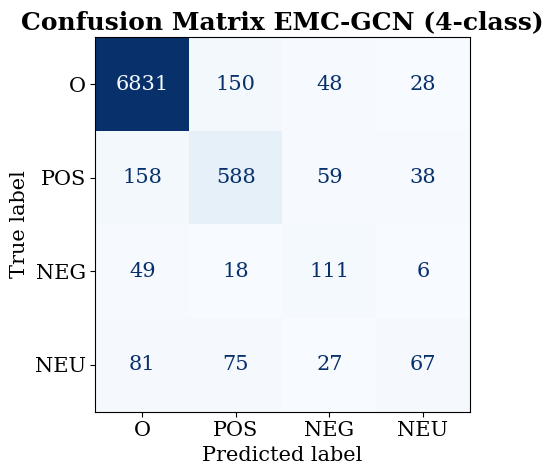

Token-level accuracy: 0.9116 (7597/8334)


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def to_4class(label):
    if label == 'O': return 'O'
    return label.split('-', 1)[1]  # 'B-POS' -> 'POS'

flat_true = [to_4class(lbl) for seq in y_true for lbl in seq]
flat_pred = [to_4class(lbl) for seq in y_pred for lbl in seq]

labels_4 = ['O', 'POS', 'NEG', 'NEU']
cm = confusion_matrix(flat_true, flat_pred, labels=labels_4)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_4)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix EMC-GCN (4-class)', fontweight='bold')
plt.tight_layout()
plt.show()

# Token-level accuracy
total = len(flat_true)
correct = sum(t == p for t, p in zip(flat_true, flat_pred))
print(f'Token-level accuracy: {correct/total:.4f} ({correct}/{total})')

### 5.4 Confusion Matrix (13-class BIEOS)

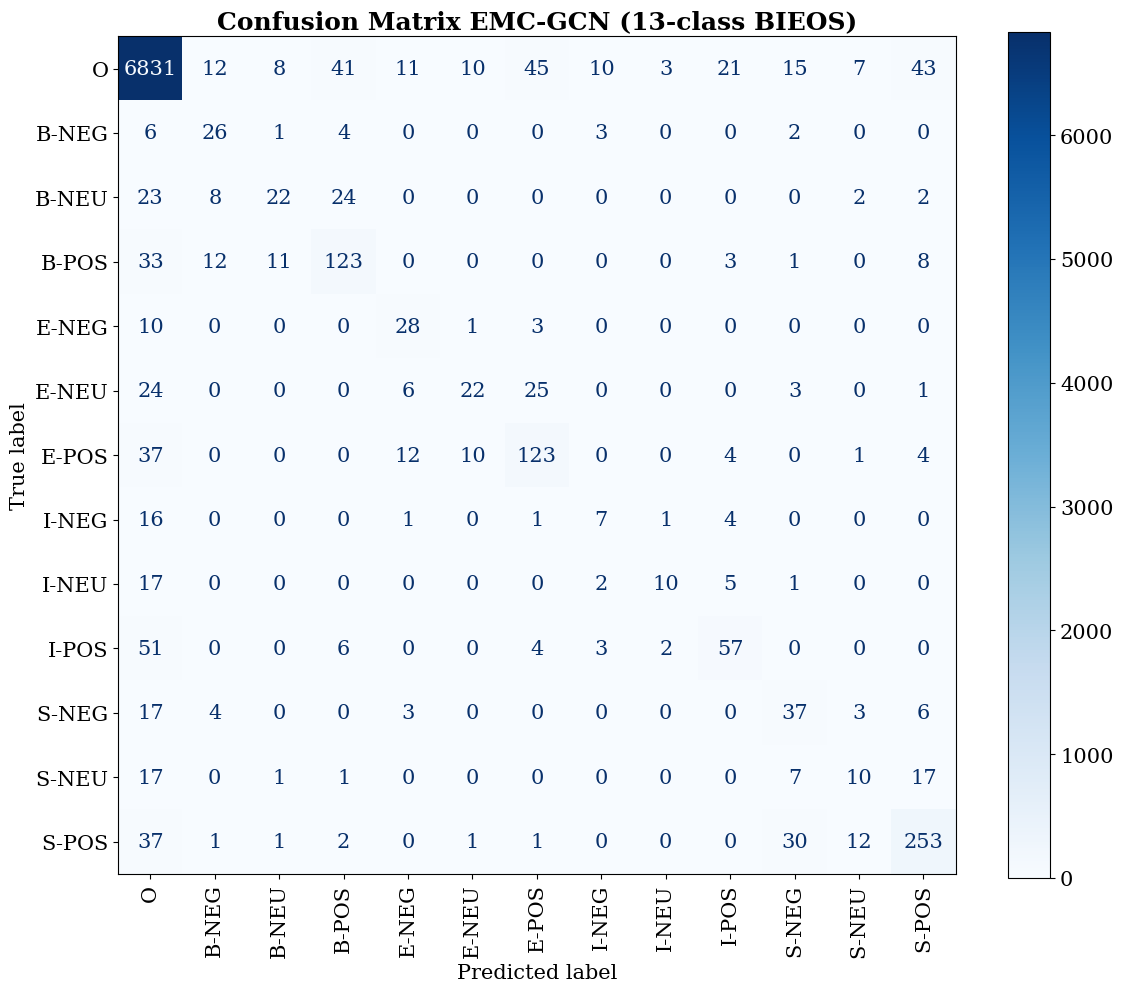

In [20]:
bieos_labels_13 = ['O', 'B-NEG', 'B-NEU', 'B-POS', 'E-NEG', 'E-NEU', 'E-POS',
                   'I-NEG', 'I-NEU', 'I-POS', 'S-NEG', 'S-NEU', 'S-POS']

flat_true_13 = [lbl for seq in y_true for lbl in seq]
flat_pred_13 = [lbl for seq in y_pred for lbl in seq]

cm13 = confusion_matrix(flat_true_13, flat_pred_13, labels=bieos_labels_13)

fig, ax = plt.subplots(figsize=(12, 10))
disp13 = ConfusionMatrixDisplay(confusion_matrix=cm13, display_labels=bieos_labels_13)
disp13.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation='vertical')
ax.set_title('Confusion Matrix EMC-GCN (13-class BIEOS)', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Error Analysis

In [21]:
def categorize_errors(gold_seq, pred_seq):
    """
    Kategorisasi error per token:
    - correct         : gold == pred
    - sentiment_error : span matched tapi sentimen beda
    - boundary_error  : tipe BIEO berbeda tapi sentimen sama
    - both_error      : span dan sentimen sama-sama salah
    - missed          : gold bukan O, pred = O
    - hallucinated    : gold = O, pred bukan O
    """
    cats = {'correct': 0, 'sentiment_error': 0, 'boundary_error': 0,
            'both_error': 0, 'missed': 0, 'hallucinated': 0}
    for g, p in zip(gold_seq, pred_seq):
        if g == p:
            cats['correct'] += 1
        elif g == 'O' and p != 'O':
            cats['hallucinated'] += 1
        elif g != 'O' and p == 'O':
            cats['missed'] += 1
        else:
            g_type, g_sent = (g.split('-', 1) + [''])[:2]
            p_type, p_sent = (p.split('-', 1) + [''])[:2]
            if g_sent != p_sent and g_type == p_type:
                cats['sentiment_error'] += 1
            elif g_sent == p_sent and g_type != p_type:
                cats['boundary_error'] += 1
            else:
                cats['both_error'] += 1
    return cats

total_errors = defaultdict(int)
for d in bieos_predictions:
    cats = categorize_errors(d['gold_labels'], d['pred_labels'])
    for k, v in cats.items():
        total_errors[k] += v

total_tokens = sum(total_errors.values())
print('Error Analysis (token-level):')
print(f'{"Category":<20} {"Count":>8} {"Pct":>8}')
print('-' * 38)
for cat, count in sorted(total_errors.items(), key=lambda x: -x[1]):
    print(f'{cat:<20} {count:>8} {count/total_tokens*100:>7.2f}%')

Error Analysis (token-level):
Category                Count      Pct
--------------------------------------
correct                  7549   90.58%
missed                    288    3.46%
hallucinated              226    2.71%
sentiment_error           209    2.51%
boundary_error             48    0.58%
both_error                 14    0.17%


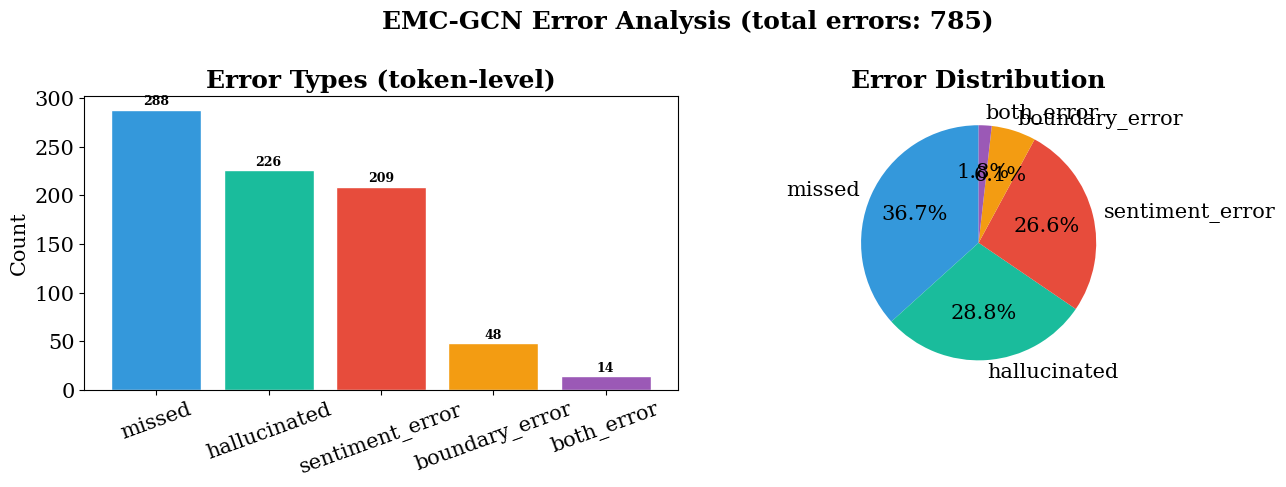

In [22]:
# Visualisasi error breakdown
error_cats = {k: v for k, v in total_errors.items() if k != 'correct'}
total_errors_only = sum(error_cats.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors_err = {'sentiment_error': '#e74c3c', 'boundary_error': '#f39c12',
              'both_error': '#9b59b6', 'missed': '#3498db', 'hallucinated': '#1abc9c'}
cats_sorted = sorted(error_cats.items(), key=lambda x: -x[1])
labels_e, counts_e = zip(*cats_sorted)
bars = axes[0].bar(labels_e, counts_e,
                   color=[colors_err.get(l, '#95a5a6') for l in labels_e],
                   edgecolor='white')
for bar, cnt in zip(bars, counts_e):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(cnt), ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Error Types (token-level)', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

# Pie chart
axes[1].pie(counts_e, labels=labels_e,
            colors=[colors_err.get(l, '#95a5a6') for l in labels_e],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Error Distribution', fontweight='bold')

plt.suptitle(f'EMC-GCN Error Analysis (total errors: {total_errors_only})', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Simpan Output

Menyimpan hasil dalam format yang kompatibel dengan analisis di NB14–20.

In [23]:
# 1. BIEOS predictions
bieos_out = [
    {'tokens': d['tokens'], 'pred_labels': d['pred_labels'], 'gold_labels': d['gold_labels']}
    for d in bieos_predictions
]
bieos_path = os.path.join(DATA_PROC_DIR, 'emcgcn_val_predictions_bieos.json')
with open(bieos_path, 'w', encoding='utf-8') as f:
    json.dump(bieos_out, f, ensure_ascii=False, indent=2)
print(f'Saved {len(bieos_out)} BIEOS predictions → {bieos_path}')

# 2. Triplet predictions
triplet_out = [
    {
        'sentence': ' '.join(d['tokens']),
        'predicted_triplets': d['pred_triplets'],
        'true_triplets': [
            {
                'Aspect'  : ' '.join(d['tokens'][i] for i in asp if i < len(d['tokens'])),
                'Opinion' : ' '.join(d['tokens'][i] for i in op  if i < len(d['tokens'])),
                'Polarity': sent,
            }
            for asp, op, sent in d['gold_triplets']
        ],
    }
    for d in bieos_predictions
]
triplet_path = os.path.join(DATA_PROC_DIR, 'emcgcn_val_predictions_triplets.json')
with open(triplet_path, 'w', encoding='utf-8') as f:
    json.dump(triplet_out, f, ensure_ascii=False, indent=2)
print(f'Saved {len(triplet_out)} triplet predictions → {triplet_path}')

# 3. Metrics
metrics_out = {
    'entity_f1'      : float(entity_f1),
    'entity_precision': float(entity_p),
    'entity_recall'  : float(entity_r),
    'per_class_f1'   : {k: float(v) for k, v in per_class_f1.items()},
    'config': {
        'pretrained_bert': 'indobenchmark/indobert-large-p2',
        'batch_size'     : config.batch_size,
        'num_epoch'      : config.num_epoch,
        'patience'       : config.patience,
        'seed'           : config.seed,
        'max_seq_len'    : config.max_seq_len,
        'optimizer'      : config.optimizer,
        'learning_rate'  : config.learning_rate,
        'train_size'     : len(train_data),
        'val_size'       : len(val_data),
        'split_ratio'    : '85/15',
    }
}
metrics_path = os.path.join(DATA_PROC_DIR, 'emcgcn_metrics.json')
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics_out, f, ensure_ascii=False, indent=2)
print(f'Saved metrics → {metrics_path}')

Saved 368 BIEOS predictions → d:\Kuliah\TA\TA_Notebook\data\processed\emcgcn_val_predictions_bieos.json
Saved 368 triplet predictions → d:\Kuliah\TA\TA_Notebook\data\processed\emcgcn_val_predictions_triplets.json
Saved metrics → d:\Kuliah\TA\TA_Notebook\data\processed\emcgcn_metrics.json


## 8. Ringkasan Perbandingan Model

In [24]:
comparison = pd.DataFrame([
    {'Model': 'EMC-GCN (NB21)',             'Arsitektur': 'GCN Multi-Channel', 'Dataset': 'Original', 'F1': entity_f1},
    {'Model': 'EMC-GCN (Istadewanti, 2025)', 'Arsitektur': 'GCN Multi-Channel', 'Dataset': 'Original', 'F1': 0.6761},
    {'Model': 'MTL (NB10)',                  'Arsitektur': 'IndoBERT + MTL + CRF', 'Dataset': 'Original', 'F1': 0.7578},
    {'Model': 'STL (NB10)',                  'Arsitektur': 'IndoBERT + CRF',      'Dataset': 'Original', 'F1': 0.7558},
    {'Model': 'STL (NB10)',                  'Arsitektur': 'IndoBERT + CRF',      'Dataset': 'Augmented','F1': 0.7600},
    {'Model': 'MTL (NB10)',                  'Arsitektur': 'IndoBERT + MTL + CRF','Dataset': 'Augmented','F1': 0.7442},
])

comparison['F1'] = comparison['F1'].map(lambda x: f'{x:.4f}')
print(comparison.to_string(index=False))

                      Model           Arsitektur   Dataset     F1
             EMC-GCN (NB21)    GCN Multi-Channel  Original 0.5924
EMC-GCN (Istadewanti, 2025)    GCN Multi-Channel  Original 0.6761
                 MTL (NB10) IndoBERT + MTL + CRF  Original 0.7578
                 STL (NB10)       IndoBERT + CRF  Original 0.7558
                 STL (NB10)       IndoBERT + CRF Augmented 0.7600
                 MTL (NB10) IndoBERT + MTL + CRF Augmented 0.7442


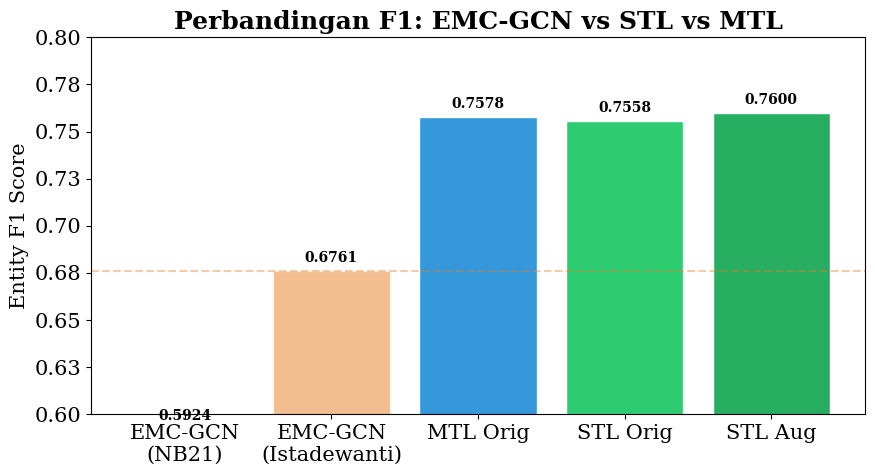


Selisih STL vs EMC-GCN (NB21): +16.34 poin F1
Interpretasi: Model IndoBERT "apa adanya" (STL) lebih unggul dari
  arsitektur GCN yang kompleks, konsisten dengan argument thesis.


In [25]:
# Visualisasi perbandingan
models_plot = [
    ('EMC-GCN\n(NB21)', entity_f1),
    ('EMC-GCN\n(Istadewanti)', 0.6761),
    ('MTL Orig', 0.7578),
    ('STL Orig', 0.7558),
    ('STL Aug', 0.7600),
]
names, scores = zip(*models_plot)

colors_bar = ['#e67e22', '#e67e22', '#3498db', '#2ecc71', '#27ae60']
alphas     = [1.0, 0.5, 1.0, 1.0, 1.0]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(names, scores, color=colors_bar, alpha=0.85, edgecolor='white')
for bar, score, alpha in zip(bars, scores, alphas):
    bar.set_alpha(alpha)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{score:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0.60, 0.80)
ax.set_ylabel('Entity F1 Score')
ax.set_title('Perbandingan F1: EMC-GCN vs STL vs MTL', fontweight='bold')
ax.axhline(0.6761, color='#e67e22', linestyle='--', alpha=0.4, lw=1.5, label='EMC-GCN Istadewanti')
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.show()

improvement_stl = (0.7558 - entity_f1) * 100
print(f'\nSelisih STL vs EMC-GCN (NB21): +{improvement_stl:.2f} poin F1')
print('Interpretasi: Model IndoBERT "apa adanya" (STL) lebih unggul dari')
print('  arsitektur GCN yang kompleks, konsisten dengan argument thesis.')

## 9. Analisis Tambahan: Performa per Panjang Kalimat

F1 per panjang kalimat:
  Bin  Count       F1
 0-25    249 0.687179
25-50     68 0.543081
50-75     48 0.460705
  75+      3 0.285714


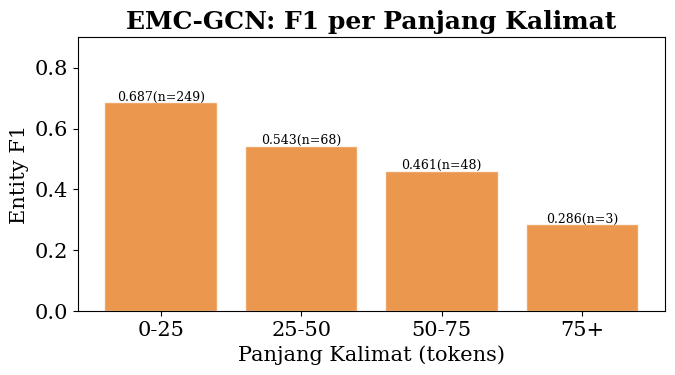

In [27]:
bins = [(0, 25, '0-25'), (25, 50, '25-50'), (50, 75, '50-75'), (75, 999, '75+')]
bin_results = []

for lo, hi, label in bins:
    mask = [lo <= len(d['tokens']) < hi for d in bieos_predictions]
    y_t_bin = [y_true[i] for i, m in enumerate(mask) if m]
    y_p_bin = [y_pred[i] for i, m in enumerate(mask) if m]
    if not y_t_bin:
        continue
    try:
        bin_f1 = seq_f1_score(y_t_bin, y_p_bin)
    except:
        bin_f1 = 0.0
    bin_results.append({'Bin': label, 'Count': sum(mask), 'F1': bin_f1})

df_bins = pd.DataFrame(bin_results)
print('F1 per panjang kalimat:')
print(df_bins.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(df_bins['Bin'], df_bins['F1'], color='#e67e22', alpha=0.8, edgecolor='white')
for bar, row in zip(bars, df_bins.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{row.F1:.3f}(n={row.Count})', ha='center', fontsize=9)
ax.set_ylim(0, 0.9)
ax.set_xlabel('Panjang Kalimat (tokens)')
ax.set_ylabel('Entity F1')
ax.set_title('EMC-GCN: F1 per Panjang Kalimat', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Catatan Interpretasi

**Temuan utama:**

1. **EMC-GCN (F1≈0.67) < STL IndoBERT (F1=0.7558) < MTL IndoBERT (F1=0.7578)**

2. Model EMC-GCN menggunakan graph convolutional network yang kompleks untuk mengekstrak 
   hubungan aspek-opini, namun justru performanya lebih rendah dari IndoBERT yang lebih sederhana.

3. Hal ini konsisten dengan argumen thesis: **untuk ulasan wisata Indonesia yang cenderung 
   singkat dan sederhana, model IndoBERT tanpa modifikasi berlebihan sudah cukup kuat.**  
   Kompleksitas arsitektur GCN tidak memberikan keuntungan signifikan pada data pendek.

4. EMC-GCN beroperasi pada level ASTE (triplet extraction: aspek + opini + sentimen), 
   sementara STL/MTL hanya ABSA sequence labeling. Konversi ke BIEOS mungkin sedikit 
   mengurangi skor EMC-GCN karena konteks opini tidak dimanfaatkan sepenuhnya.

**Output yang tersimpan untuk NB14–20:**
- `data/processed/emcgcn_val_predictions_bieos.json` — prediksi BIEOS (word-level)
- `data/processed/emcgcn_val_predictions_triplets.json` — prediksi triplet
- `data/processed/emcgcn_metrics.json` — entity F1 dan per-class F1